## Vehicle Insurance Claim Fraud Detection

In [82]:
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from scipy.stats import chi2_contingency
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import statsmodels.api as sm
import shap
shap.initjs()
import joblib
import os

## Load the dataset

In [2]:
path = kagglehub.dataset_download("shivamb/vehicle-claim-fraud-detection")
df = pd.read_csv(f"{path}/fraud_oracle.csv")
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [3]:
df.shape

(15420, 33)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  str  
 14  VehiclePrice          15420 non-null  str  
 15  FraudFound_P          15420 non-null  int64
 16  PolicyNumber   

In [5]:
df.isna().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

In [6]:
df_for_eda = df.copy()

In [7]:
df["Age"] = df["Age"].replace(0, np.nan)

In [8]:
#target class is highly imbalanced
df['FraudFound_P'].value_counts() / df.shape[0] * 100

FraudFound_P
0    94.014267
1     5.985733
Name: count, dtype: float64

In [9]:
columns_to_check = ['Days_Policy_Accident', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'NumberOfSuppliments', 'NumberOfCars']

for col in columns_to_check:
    print(f"{col}: {df[col].unique()}")

Days_Policy_Accident: <StringArray>
['more than 30', '15 to 30', 'none', '1 to 7', '8 to 15']
Length: 5, dtype: str
PastNumberOfClaims: <StringArray>
['none', '1', '2 to 4', 'more than 4']
Length: 4, dtype: str
AgeOfVehicle: <StringArray>
[    '3 years',     '6 years',     '7 years', 'more than 7',     '5 years',
         'new',     '4 years',     '2 years']
Length: 8, dtype: str
AgeOfPolicyHolder: <StringArray>
['26 to 30', '31 to 35', '41 to 50', '51 to 65', '21 to 25', '36 to 40',
 '16 to 17',  'over 65', '18 to 20']
Length: 9, dtype: str
NumberOfSuppliments: <StringArray>
['none', 'more than 5', '3 to 5', '1 to 2']
Length: 4, dtype: str
NumberOfCars: <StringArray>
['3 to 4', '1 vehicle', '2 vehicles', '5 to 8', 'more than 8']
Length: 5, dtype: str


In [10]:
df.isnull().sum()

Month                     0
WeekOfMonth               0
DayOfWeek                 0
Make                      0
AccidentArea              0
DayOfWeekClaimed          0
MonthClaimed              0
WeekOfMonthClaimed        0
Sex                       0
MaritalStatus             0
Age                     320
Fault                     0
PolicyType                0
VehicleCategory           0
VehiclePrice              0
FraudFound_P              0
PolicyNumber              0
RepNumber                 0
Deductible                0
DriverRating              0
Days_Policy_Accident      0
Days_Policy_Claim         0
PastNumberOfClaims        0
AgeOfVehicle              0
AgeOfPolicyHolder         0
PoliceReportFiled         0
WitnessPresent            0
AgentType                 0
NumberOfSuppliments       0
AddressChange_Claim       0
NumberOfCars              0
Year                      0
BasePolicy                0
dtype: int64

In [11]:
days_policy_accident_map = {
    'none': 0,
    '1 to 7': 1,
    '8 to 15': 2,
    '15 to 30': 3,
    'more than 30': 4
}

df['Days_Policy_Accident'] = df['Days_Policy_Accident'].map(days_policy_accident_map)

In [12]:
days_past_number_map = {
    'none': 0,
    '1': 1,
    '2 to 4': 2,
    'more than 4': 3
}

df['PastNumberOfClaims'] = df['PastNumberOfClaims'].map(days_past_number_map)

In [13]:
days_age_vehicle_map = {
    'new': 0,
    '2 years': 1,
    '3 years': 2,
    '4 years': 3,
    '5 years': 4,
    '6 years': 5,
    '7 years': 6,
    'more than 7': 7
}

df['AgeOfVehicle'] = df['AgeOfVehicle'].map(days_age_vehicle_map)

In [14]:
days_age_policy_holder_map = {
    '16 to 17': 0,
    '18 to 20': 1,
    '21 to 25': 2,
    '26 to 30': 3,
    '31 to 35': 4,
    '36 to 40': 5,
    '41 to 50': 6,
    '51 to 65': 7,
    'over 65': 8
}

df['AgeOfPolicyHolder'] = df['AgeOfPolicyHolder'].map(days_age_policy_holder_map)

In [15]:
days_number_supplements_map = {
    'none': 0,
    '1 to 2': 1,
    '3 to 5': 2,
    'more than 5': 3
}

df['NumberOfSuppliments'] = df['NumberOfSuppliments'].map(days_number_supplements_map)

In [16]:
days_number_cars_map = {
    '1 vehicle': 0,
    '2 vehicles': 1,
    '3 to 4': 2,
    '5 to 8': 3,
    'more than 8': 4
}

df['NumberOfCars'] = df['NumberOfCars'].map(days_number_cars_map)

In [17]:
df['VehiclePrice'].unique()

<StringArray>
['more than 69000',  '20000 to 29000',  '30000 to 39000', 'less than 20000',
  '40000 to 59000',  '60000 to 69000']
Length: 6, dtype: str

In [ ]:
days_vehicle_price_map = {
    'less than 20000': 0,
    '20000 to 29000': 1,
    '30000 to 39000': 2,
    '40000 to 59000': 3,
    '60000 to 69000': 4,
    'more than 69000': 5
}

df['VehiclePrice'] = df['VehiclePrice'].map(days_vehicle_price_map)

In [19]:
days_days_policy_map = {
    'none': 0,
    '8 to 15': 1,
    '15 to 30': 2,
    'more than 30': 3
}

df['Days_Policy_Claim'] = df['Days_Policy_Claim'].map(days_days_policy_map)

In [20]:
df['Days_Policy_Claim'].unique()

array([3, 2, 1, 0])

In [21]:
print(df['PolicyNumber'].nunique() == len(df))

True


In [22]:
df = df.drop(columns=['PolicyNumber'])

In [23]:
df['MonthClaimed'].isna().sum()

np.int64(0)

In [24]:
print((df['MonthClaimed'] == '0').sum())
print(df[df['MonthClaimed'] == '0']['FraudFound_P'].mean())

1
0.0


In [25]:
df = df[df['MonthClaimed'] != '0']

In [26]:
df['WeekOfMonth'].unique()

array([5, 3, 2, 4, 1])

In [27]:
df['WeekOfMonthClaimed'].unique()

array([1, 4, 2, 3, 5])

In [28]:
month_mapping = {
    "Jan": 1,
    "Feb": 2,
    "Mar": 3,
    "Apr": 4,
    "May": 5,
    "Jun": 6,
    "Jul": 7,
    "Aug": 8,
    "Sep": 9,
    "Oct": 10,
    "Nov": 11,
    "Dec": 12
}
df['Month'] = df['Month'].map(month_mapping)
df['MonthClaimed'] = df['MonthClaimed'].map(month_mapping)
df['MonthClaimed'] = df['MonthClaimed'].astype(int)

In [29]:
month_diff = df['MonthClaimed'] - df['Month']
month_diff = month_diff.where(month_diff >= 0, month_diff + 12)

df['claim_delay_approx'] = month_diff * 4 + (df['WeekOfMonthClaimed'] - df['WeekOfMonth'])

In [30]:
df['claim_delay_approx'].describe()

count    15419.000000
mean         1.405409
std          3.403515
min         -3.000000
25%          0.000000
50%          1.000000
75%          1.000000
max         48.000000
Name: claim_delay_approx, dtype: float64

In [31]:
df[df['claim_delay_approx'] < 0][['Month', 'WeekOfMonth', 'MonthClaimed', 'WeekOfMonthClaimed', 'claim_delay_approx']]

,Month,WeekOfMonth,MonthClaimed,WeekOfMonthClaimed,claim_delay_approx
5247,9,4,9,3,-1
9553,4,3,4,1,-2
14339,11,5,11,2,-3


In [32]:
#we can do that cause there are only 3 rows
df['claim_delay_approx'] = df['claim_delay_approx'].clip(lower=0)

In [33]:
categorical_cols = ['Make', 'AccidentArea', 'Sex', 'MaritalStatus', 'Fault',
                     'PolicyType', 'VehicleCategory', 'PoliceReportFiled',
                     'WitnessPresent', 'AgentType', 'AddressChange_Claim',
                     'BasePolicy', 'DayOfWeek', 'DayOfWeekClaimed']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [34]:
df.head()

,Month,WeekOfMonth,MonthClaimed,WeekOfMonthClaimed,Age,VehiclePrice,FraudFound_P,RepNumber,Deductible,DriverRating,...,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,DayOfWeekClaimed_Monday,DayOfWeekClaimed_Saturday,DayOfWeekClaimed_Sunday,DayOfWeekClaimed_Thursday,DayOfWeekClaimed_Tuesday,DayOfWeekClaimed_Wednesday
0,12,5,1,1,21.0,4,0,12,300,1,...,False,False,False,True,False,False,False,False,True,False
1,1,3,1,4,34.0,4,0,15,400,4,...,False,False,False,True,True,False,False,False,False,False
2,10,5,11,2,47.0,4,0,7,400,3,...,False,False,False,False,False,False,False,True,False,False
3,6,2,7,1,65.0,1,0,4,400,2,...,False,False,False,False,False,False,False,False,False,False
4,1,5,2,2,27.0,4,0,3,400,1,...,False,False,False,False,False,False,False,False,True,False


In [35]:
print(df.shape)
print(df.dtypes.value_counts())

(15419, 74)
bool       55
int64      18
float64     1
Name: count, dtype: int64


In [36]:
## adding some null values to the dataset for my training purpose
np.random.seed(42)

for col in ['Age', 'Deductible', 'DriverRating']:
    mask = np.random.rand(len(df)) < 0.1  # 10% missing values
    df.loc[mask, col] = np.nan

In [37]:
df.isna().sum()

Month                            0
WeekOfMonth                      0
MonthClaimed                     0
WeekOfMonthClaimed               0
Age                           1870
                              ... 
DayOfWeekClaimed_Saturday        0
DayOfWeekClaimed_Sunday          0
DayOfWeekClaimed_Thursday        0
DayOfWeekClaimed_Tuesday         0
DayOfWeekClaimed_Wednesday       0
Length: 74, dtype: int64

In [38]:
df.columns

Index(['Month', 'WeekOfMonth', 'MonthClaimed', 'WeekOfMonthClaimed', 'Age',
       'VehiclePrice', 'FraudFound_P', 'RepNumber', 'Deductible',
       'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'NumberOfSuppliments', 'NumberOfCars', 'Year', 'claim_delay_approx',
       'Make_BMW', 'Make_Chevrolet', 'Make_Dodge', 'Make_Ferrari', 'Make_Ford',
       'Make_Honda', 'Make_Jaguar', 'Make_Lexus', 'Make_Mazda', 'Make_Mecedes',
       'Make_Mercury', 'Make_Nisson', 'Make_Pontiac', 'Make_Porche',
       'Make_Saab', 'Make_Saturn', 'Make_Toyota', 'Make_VW',
       'AccidentArea_Urban', 'Sex_Male', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'MaritalStatus_Widow', 'Fault_Third Party',
       'PolicyType_Sedan - Collision', 'PolicyType_Sedan - Liability',
       'PolicyType_Sport - All Perils', 'PolicyType_Sport - Collision',
       'PolicyType_Sport - Liability', 'PolicyType_Utility - All Perils',


## EDA

In [39]:
df_for_eda = df_for_eda.drop(columns=['PolicyNumber'])

In [40]:
df_for_eda.dtypes.value_counts()

str      24
int64     8
Name: count, dtype: int64

In [41]:
numeric_columns = df_for_eda.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns

['WeekOfMonth',
 'WeekOfMonthClaimed',
 'Age',
 'FraudFound_P',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Year']

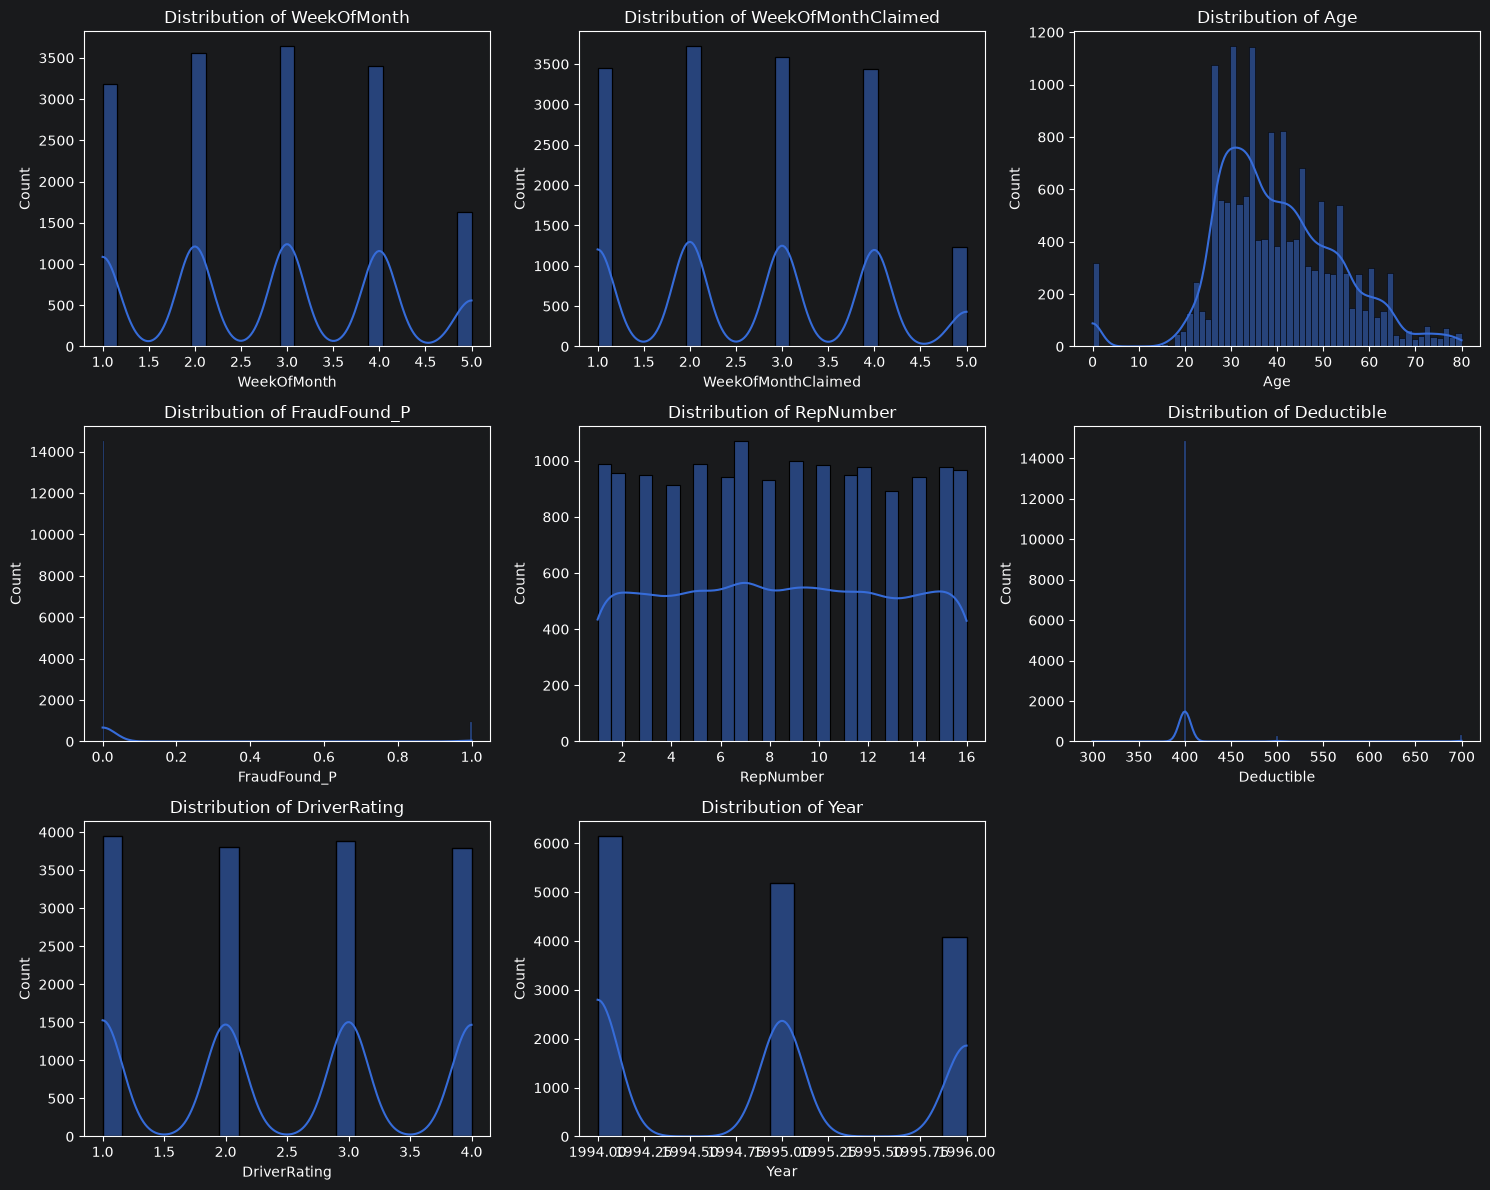

In [42]:
numeric_columns = df_for_eda.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 3
n_rows = math.ceil(len(numeric_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.histplot(df_for_eda[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

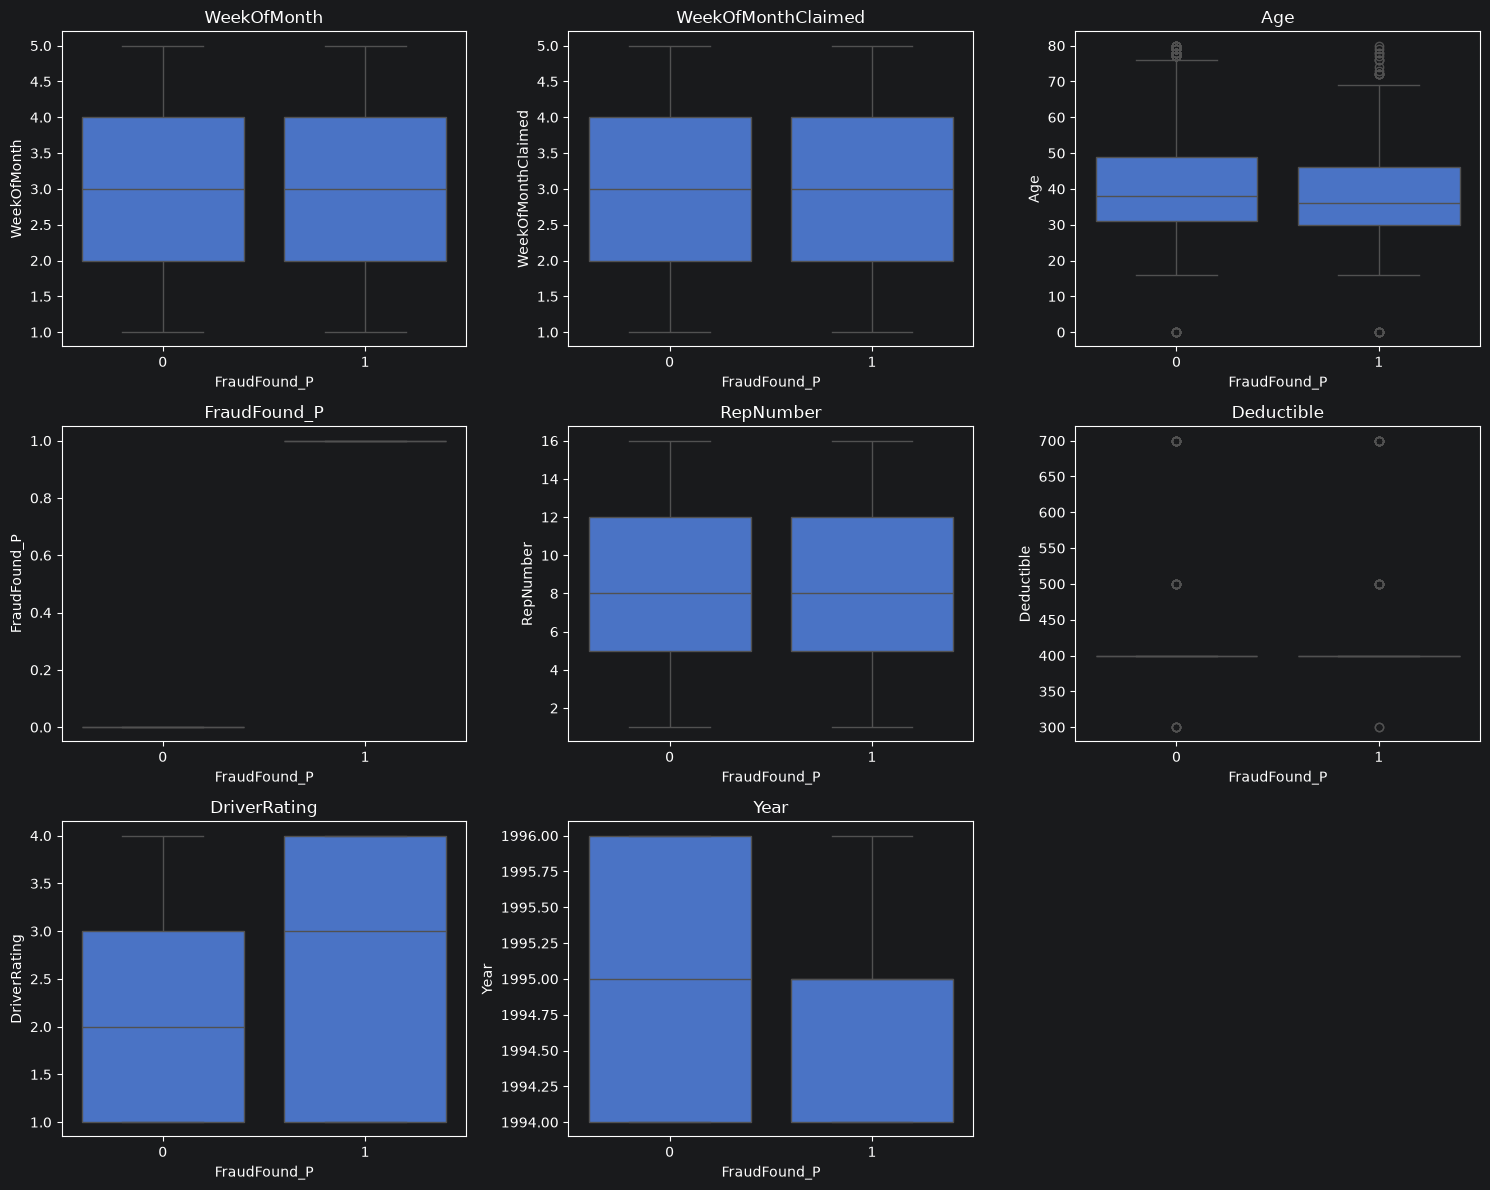

In [43]:
n_cols = 3
n_rows = math.ceil(len(numeric_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(data=df_for_eda, x='FraudFound_P', y=col, ax=axes[i])
    axes[i].set_title(f'{col}')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [44]:
df_for_eda.groupby('FraudFound_P')['Year'].value_counts(normalize=True)

FraudFound_P  Year
0             1994    0.395461
              1995    0.337587
              1996    0.266952
1             1994    0.443120
              1995    0.326111
              1996    0.230769
Name: proportion, dtype: float64

In [45]:
for col in ['Fault', 'PolicyType', 'PoliceReportFiled', 'AccidentArea', 'WitnessPresent']:
    print(df_for_eda.groupby(col)['FraudFound_P'].mean().sort_values(ascending=False))

Fault
Policy Holder    0.078896
Third Party      0.008831
Name: FraudFound_P, dtype: float64
PolicyType
Sport - Collision       0.137931
Utility - All Perils    0.120588
Sedan - All Perils      0.100563
Utility - Collision     0.100000
Sedan - Collision       0.068768
Sedan - Liability       0.007219
Sport - All Perils      0.000000
Sport - Liability       0.000000
Utility - Liability     0.000000
Name: FraudFound_P, dtype: float64
PoliceReportFiled
No     0.060499
Yes    0.037383
Name: FraudFound_P, dtype: float64
AccidentArea
Rural    0.083229
Urban    0.057155
Name: FraudFound_P, dtype: float64
WitnessPresent
No     0.060001
Yes    0.034483
Name: FraudFound_P, dtype: float64


In [46]:
df_for_eda['PolicyType'].value_counts()

PolicyType
Sedan - Collision       5584
Sedan - Liability       4987
Sedan - All Perils      4087
Sport - Collision        348
Utility - All Perils     340
Utility - Collision       30
Sport - All Perils        22
Utility - Liability       21
Sport - Liability          1
Name: count, dtype: int64

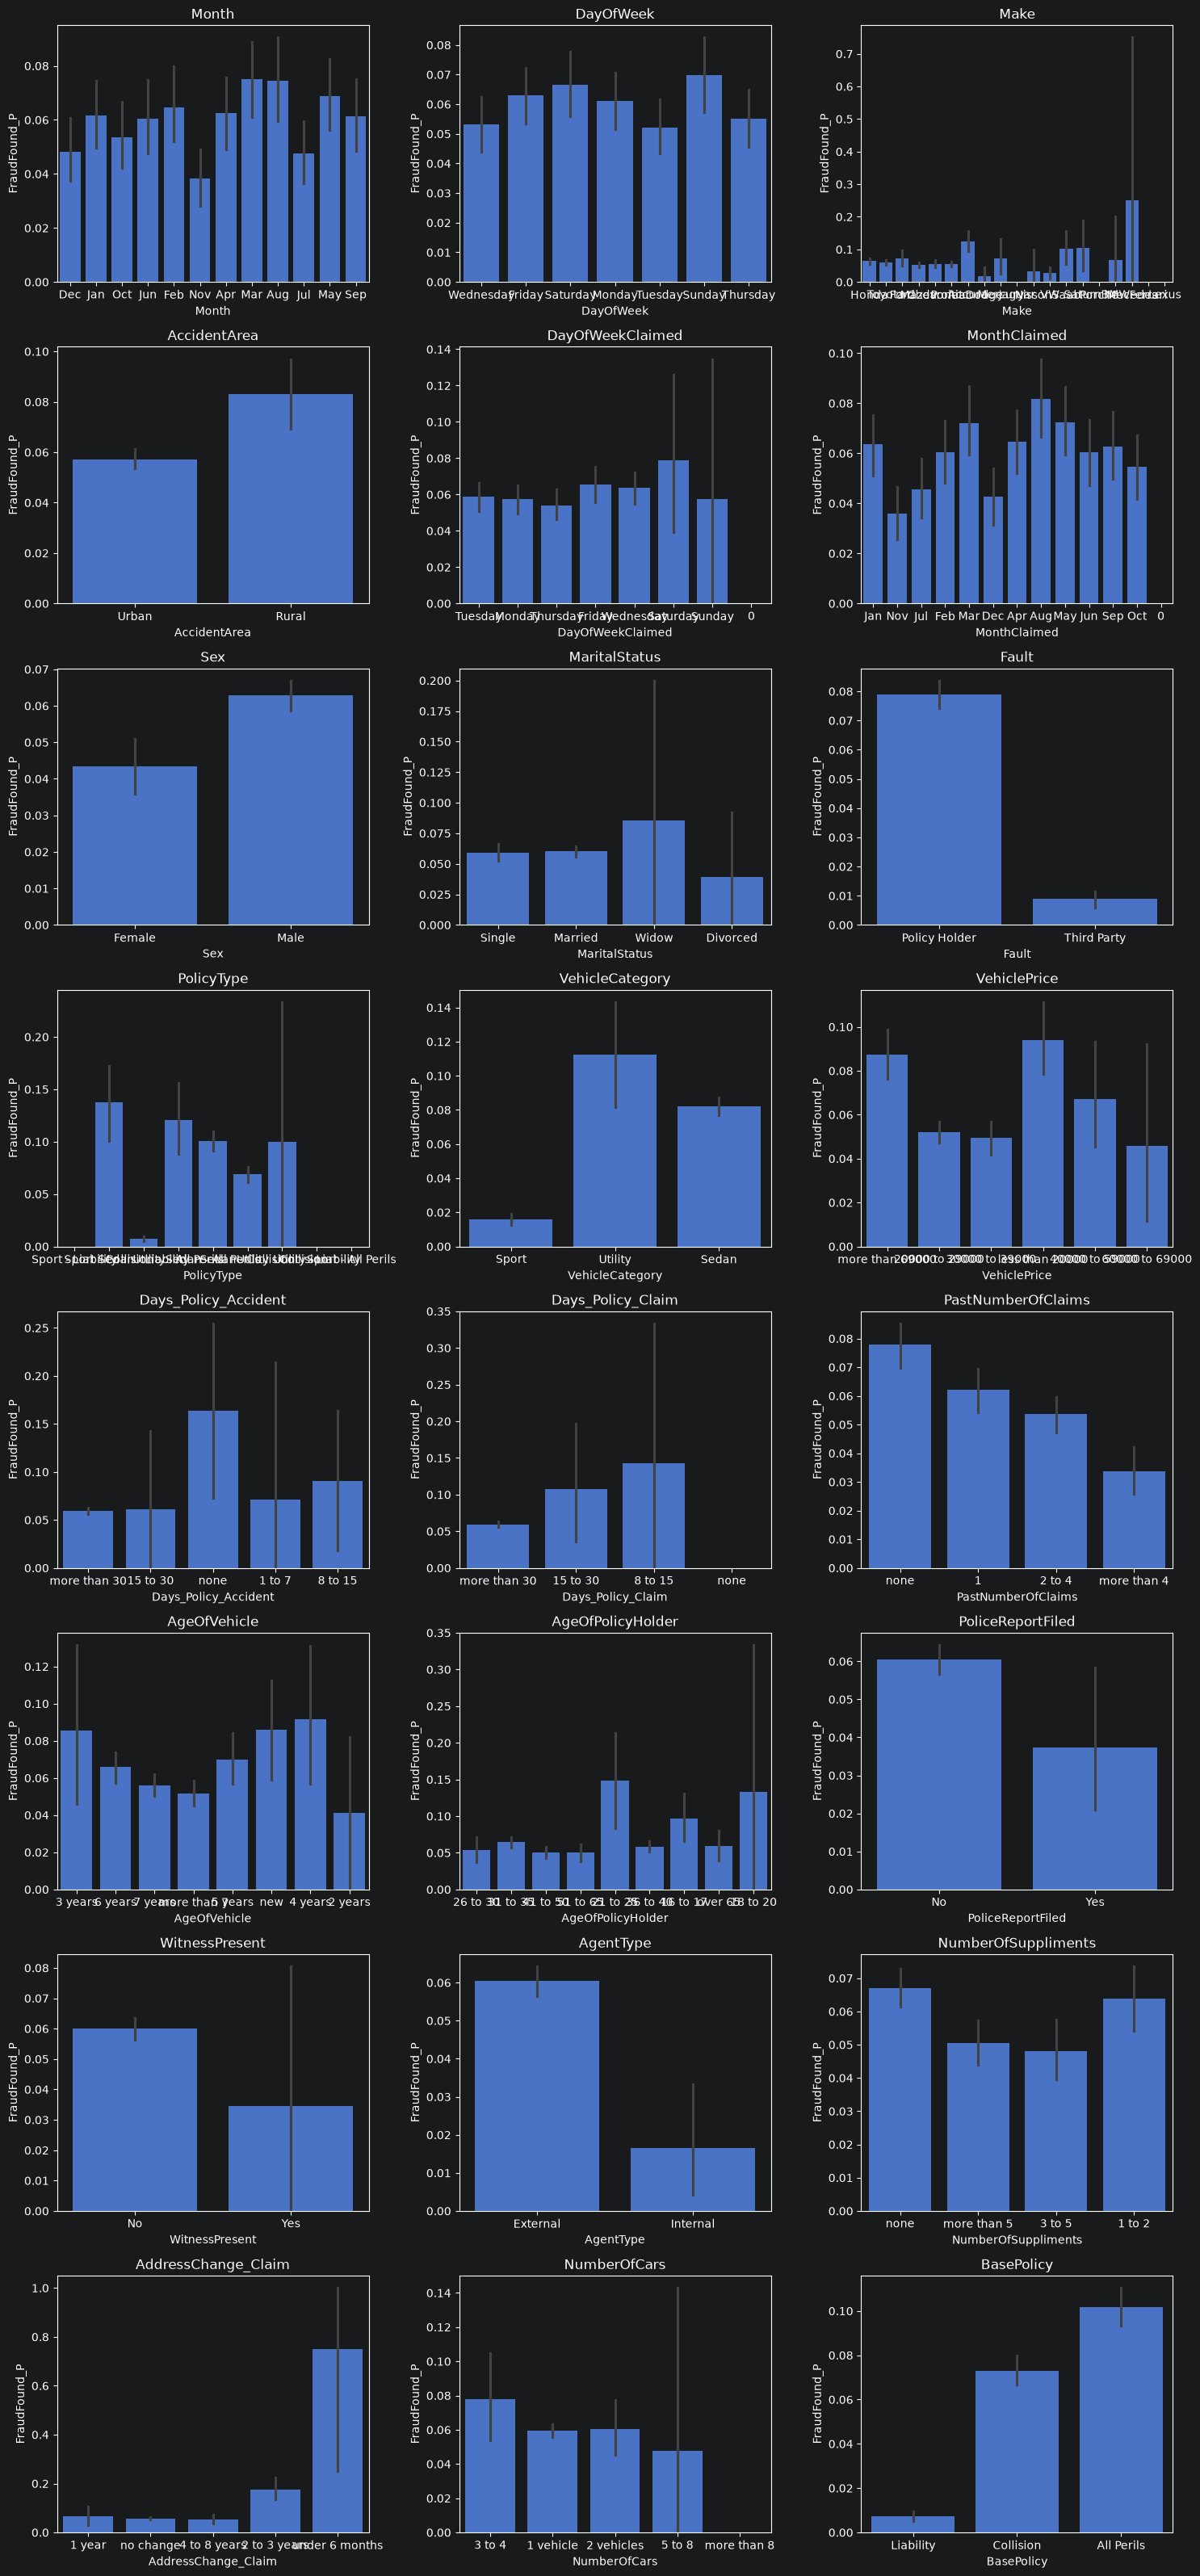

In [47]:
categorical_cols = df_for_eda.select_dtypes(include=['str']).columns.tolist()

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.barplot(data=df_for_eda, x=col, y='FraudFound_P', ax=axes[i])
    axes[i].set_title(f'{col}')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [48]:
df_for_eda['Deductible'].value_counts()

Deductible
400    14838
700      311
500      263
300        8
Name: count, dtype: int64

In [49]:
print(df_for_eda['AddressChange_Claim'].value_counts())
print(df_for_eda['AgentType'].value_counts())

AddressChange_Claim
no change         14324
4 to 8 years        631
2 to 3 years        291
1 year              170
under 6 months        4
Name: count, dtype: int64
AgentType
External    15179
Internal      241
Name: count, dtype: int64


<Axes: xlabel='FraudFound_P', ylabel='count'>

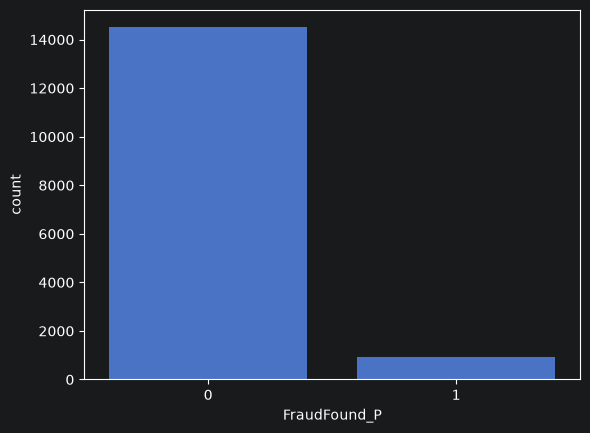

In [50]:
sns.countplot(data=df_for_eda, x="FraudFound_P")

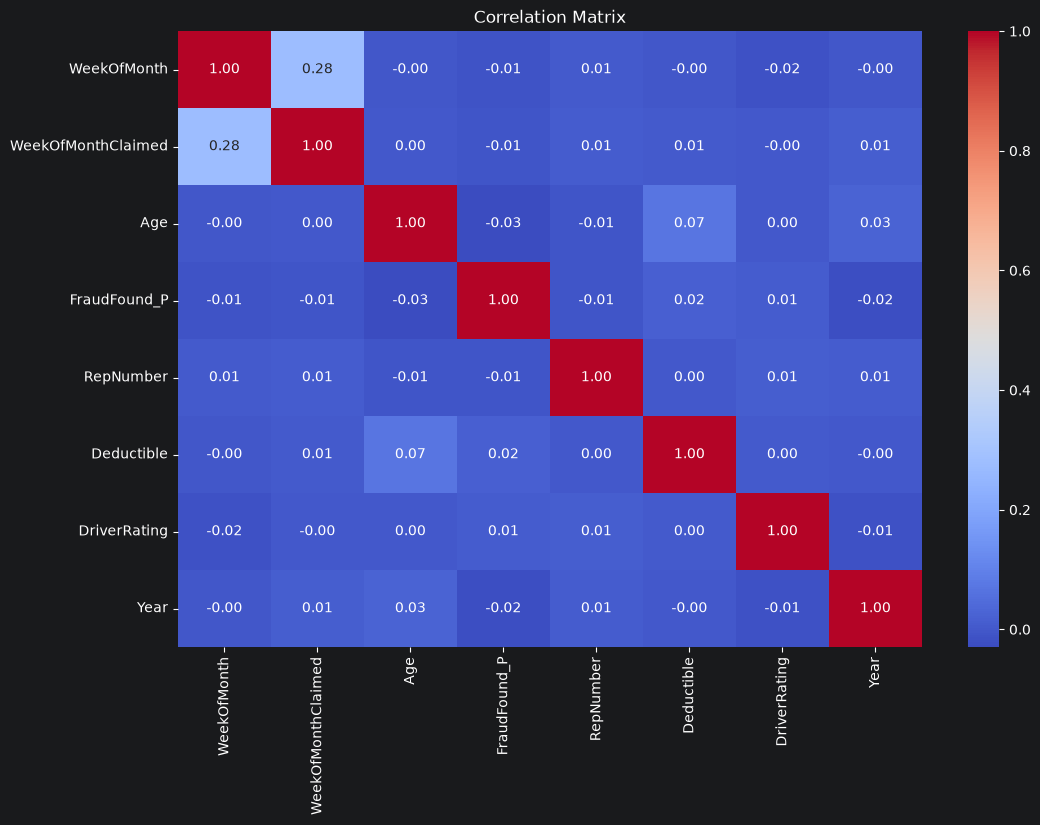

In [51]:
corr = df_for_eda.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Modeling

In [52]:
X = df.drop('FraudFound_P', axis=1)
y = df['FraudFound_P']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [54]:
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 12335 samples
Test set size: 3084 samples


In [55]:
y_train.value_counts(normalize=True)

FraudFound_P
0    0.94017
1    0.05983
Name: proportion, dtype: float64

In [56]:
y_test.value_counts(normalize=True)

FraudFound_P
0    0.940013
1    0.059987
Name: proportion, dtype: float64

In [57]:
X_train.isna().sum()

Month                            0
WeekOfMonth                      0
MonthClaimed                     0
WeekOfMonthClaimed               0
Age                           1509
                              ... 
DayOfWeekClaimed_Saturday        0
DayOfWeekClaimed_Sunday          0
DayOfWeekClaimed_Thursday        0
DayOfWeekClaimed_Tuesday         0
DayOfWeekClaimed_Wednesday       0
Length: 73, dtype: int64

In [58]:
X_test.isna().sum()

Month                           0
WeekOfMonth                     0
MonthClaimed                    0
WeekOfMonthClaimed              0
Age                           361
                             ... 
DayOfWeekClaimed_Saturday       0
DayOfWeekClaimed_Sunday         0
DayOfWeekClaimed_Thursday       0
DayOfWeekClaimed_Tuesday        0
DayOfWeekClaimed_Wednesday      0
Length: 73, dtype: int64

In [ ]:
imp_median = SimpleImputer(strategy='median')

In [ ]:
X_train.dtypes.value_counts()

In [61]:
#statistical test for Fault
df_for_eda['Fault'].value_counts()

Fault
Policy Holder    11230
Third Party       4190
Name: count, dtype: int64

In [62]:
df_for_eda_train = df_for_eda.loc[X_train.index]

In [63]:
print(len(df_for_eda_train) == len(X_train))  # powinno być True
print((df_for_eda_train.index == X_train.index).all())  # powinno być True — dokładnie ten sam zestaw i kolejność

True
True


In [64]:
table = pd.crosstab(df_for_eda_train['Fault'], df_for_eda_train['FraudFound_P'])
table

FraudFound_P,0,1
Fault,,
Policy Holder,8258,706
Third Party,3339,32


In [65]:
ch2_stat, p_value, dof, expected = chi2_contingency(table)
print(f"Chi-squared statistic: {ch2_stat}")
print(f"P-value: {p_value:.50f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)

Chi-squared statistic: 207.7228070449204
P-value: 0.00000000000000000000000000000000000000000000004312
Degrees of freedom: 1
Expected frequencies:
[[8427.68609647  536.31390353]
 [3169.31390353  201.68609647]]


We can se that the p-value is very small, which indicates that there is a significant association between the 'Fault' variable and the target variable 'FraudFound_P'. This suggests that the 'Fault' variable may be an important feature for predicting insurance claim fraud.

In [ ]:
smote = SMOTE(random_state=42)
model = XGBClassifier(random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = Pipeline([
    ('imputer', imp_median),
    ('smote', smote),
    ('model', model)
])

parameters = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [5, 10],
    'model__learning_rate': [0.1, 0.5]
}

clf = GridSearchCV(
    estimator=pipeline,
    param_grid=parameters,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1
)

clf.fit(X_train, y_train)

In [ ]:
print(clf.best_params_)
print(clf.best_score_)
best_pipeline = clf.best_estimator_

# Wyciągamy dopasowany imputer z pipeline do dalszej analizy (SHAP, regresja logistyczna)
imputer_fitted = best_pipeline.named_steps['imputer']
X_train_imputed = pd.DataFrame(imputer_fitted.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer_fitted.transform(X_test), columns=X_test.columns, index=X_test.index)

In [ ]:
y_probs = best_pipeline.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

In [69]:
print(len(precisions), len(recalls), len(thresholds))

3085 3085 3084


In [70]:
pr_df = pd.DataFrame({
    'threshold': thresholds,
    'precision': precisions[:-1],
    'recall': recalls[:-1]
})

In [71]:
candidates = pr_df[pr_df['recall'] >= 0.7]
best_row_recall = candidates.loc[candidates['precision'].idxmax()]
best_row_recall

threshold    0.041779
precision    0.196078
recall       0.702703
Name: 2421, dtype: float64

In [72]:
candidates = pr_df[pr_df['precision'] >= 0.5]
best_row_precision = candidates.loc[candidates['recall'].idxmax()]
best_row_precision

threshold    0.333351
precision    0.500000
recall       0.156757
Name: 3026, dtype: float64

Ten sam model, w zależności od kontekstu wdrożenia, wymaga zupełnie innego progu decyzyjnego.

- **Automatyczna blokada roszczenia** → próg ~0.33 (precision ≥ 50%): połowa alarmów jest trafna, ale łapiemy tylko ~16% fraudów. Fałszywy alarm kosztuje zirytowanego klienta i obsługę reklamacji, więc precyzja jest ważniejsza.
- **Flagowanie do manualnej weryfikacji** → próg ~0.04 (recall ≥ 70%): łapiemy 70% fraudów kosztem tego, że 80% flag będzie fałszywymi alarmami. Fałszywy alarm to tylko kilka minut pracy analityka, a przegapiony fraud to realna strata finansowa.

Do tego zadania przyjmuję próg **0.091** jako świadomy kompromis — wyższy recall niż przy progu 0.33, wyższa precyzja niż przy 0.04. System służy do flagowania do manualnej weryfikacji.

In [ ]:
threshold = 0.091
y_pred_final = y_probs >= threshold

In [74]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.98      0.82      0.89      2899
           1       0.19      0.70      0.30       185

    accuracy                           0.81      3084
   macro avg       0.59      0.76      0.60      3084
weighted avg       0.93      0.81      0.85      3084



In [75]:
print(confusion_matrix(y_test, y_pred_final))

[[2366  533]
 [  56  129]]


In [76]:
xgb_model = best_pipeline.named_steps['model']

C:\Users\lespa\AppData\Local\Temp\ipykernel_21344\4171394110.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_tree, X_test_imputed)


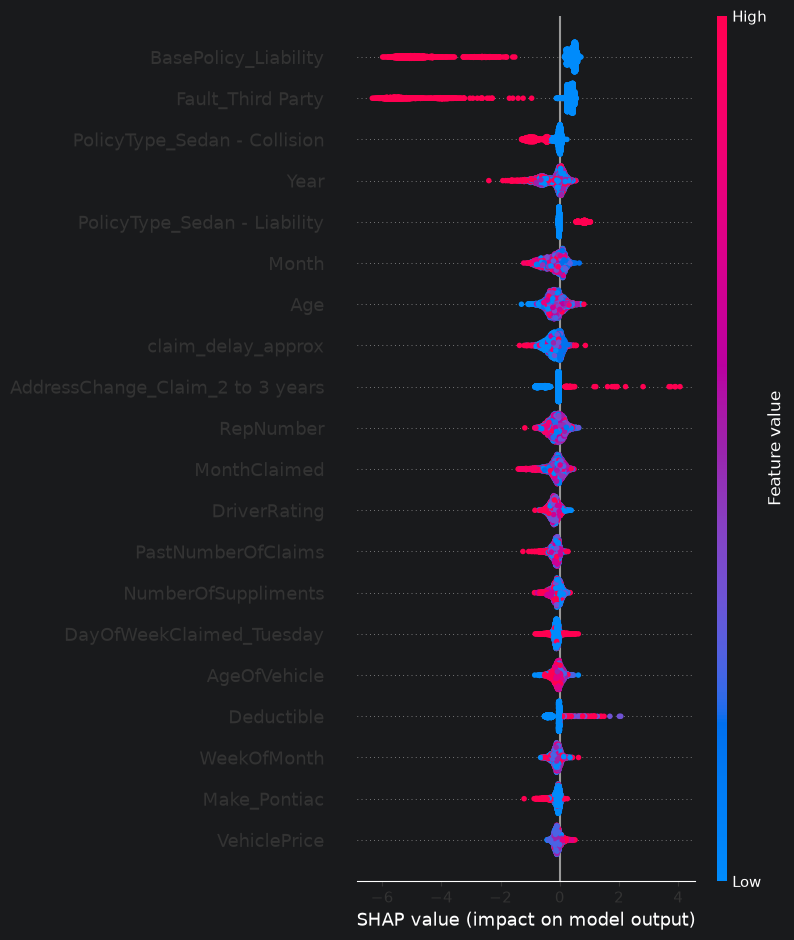

In [77]:
tree = shap.TreeExplainer(xgb_model)
shap_values_tree = tree.shap_values(X_test_imputed)
shap.summary_plot(shap_values_tree, X_test_imputed)

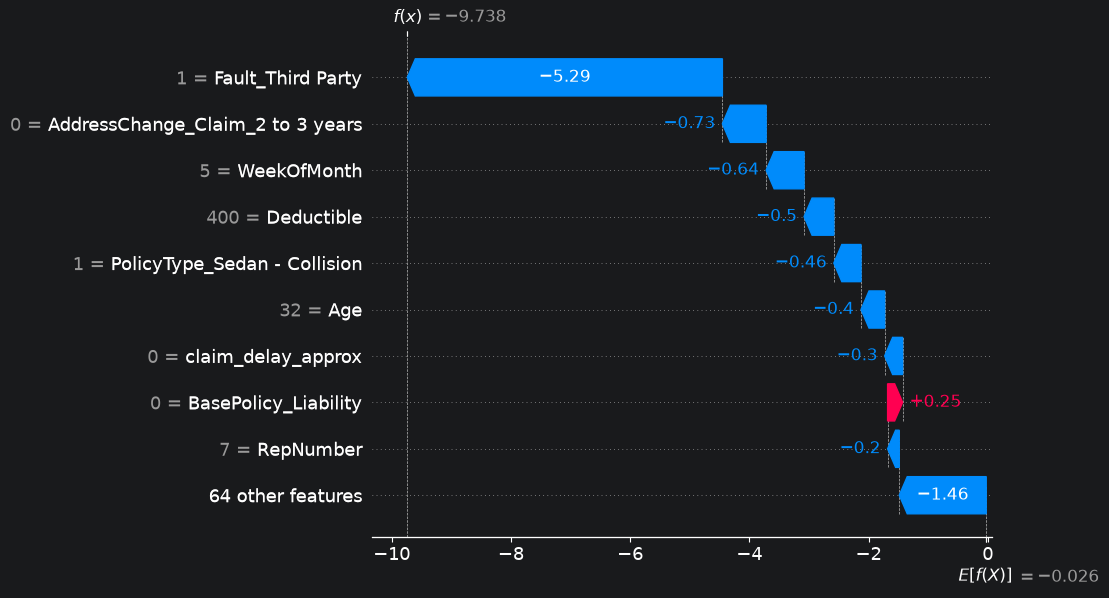

In [78]:
explanation = tree(X_test_imputed)
shap.waterfall_plot(explanation[0])

## Logistic regression (statistic training)

In [79]:
# Krok 1: usuń binary kolumny z quasi-perfekcyjną separacją
# (< 10 przypadków fraudu w jednej z grup → Hessian staje się osobliwy)
MIN_FRAUD = 10
cols_separation = []
for col in X_train_imputed.columns:
    if X_train_imputed[col].dropna().nunique() == 2:
        for v in X_train_imputed[col].dropna().unique():
            if y_train[X_train_imputed[col] == v].sum() < MIN_FRAUD:
                cols_separation.append(col)
                break

# Krok 2: usuń PolicyType — jest iloczynem VehicleCategory × BasePolicy,
# więc przy obu tych zmiennych w modelu tworzy quasi-perfekcyjną koliniearność
cols_policy_type = [c for c in X_train_imputed.columns if c.startswith('PolicyType_')]

cols_to_drop = list(set(cols_separation + cols_policy_type))
X_clean = sm.add_constant(X_train_imputed.drop(columns=cols_to_drop))

# Krok 3: usuń kolumny z zerową diagonalą QR (perfekcyjna koliniearność)
_, R = np.linalg.qr(X_clean.values)
diag = np.abs(np.diag(R))
qr_collinear = X_clean.columns[diag == 0].tolist()
X_logit = X_clean.drop(columns=qr_collinear)

print(f"Usunięto {len(cols_separation)} kolumn (quasi-separation): {sorted(cols_separation)}")
print(f"Usunięto {len(cols_policy_type)} kolumn (PolicyType): {sorted(cols_policy_type)}")
print(f"Usunięto {len(qr_collinear)} kolumn (QR collinear): {qr_collinear}")
print(f"\nFinalna liczba zmiennych w modelu: {X_logit.shape[1]}\n")

log_reg = sm.Logit(y_train, X_logit)
result_reg = log_reg.fit(method='newton', maxiter=1000, disp=False)
print(result_reg.summary())

Usunięto 20 kolumn (quasi-separation): ['AddressChange_Claim_under 6 months', 'AgentType_Internal', 'DayOfWeekClaimed_Saturday', 'DayOfWeekClaimed_Sunday', 'Make_BMW', 'Make_Dodge', 'Make_Ferrari', 'Make_Jaguar', 'Make_Mecedes', 'Make_Mercury', 'Make_Nisson', 'Make_Porche', 'Make_Saturn', 'Make_VW', 'MaritalStatus_Widow', 'PolicyType_Sport - All Perils', 'PolicyType_Sport - Liability', 'PolicyType_Utility - Collision', 'PolicyType_Utility - Liability', 'WitnessPresent_Yes']
Usunięto 8 kolumn (PolicyType): ['PolicyType_Sedan - Collision', 'PolicyType_Sedan - Liability', 'PolicyType_Sport - All Perils', 'PolicyType_Sport - Collision', 'PolicyType_Sport - Liability', 'PolicyType_Utility - All Perils', 'PolicyType_Utility - Collision', 'PolicyType_Utility - Liability']
Usunięto 1 kolumn (QR collinear): ['Make_Lexus']

Finalna liczba zmiennych w modelu: 49

                           Logit Regression Results                           
Dep. Variable:           FraudFound_P   No. Observations

## Model for Docker/FastAPI

In [81]:
joblib.dump(best_pipeline, 'fraud_model_pipeline.pkl')

['fraud_model_pipeline.pkl']

In [83]:
print(os.path.exists('fraud_model_pipeline.pkl'))

True
